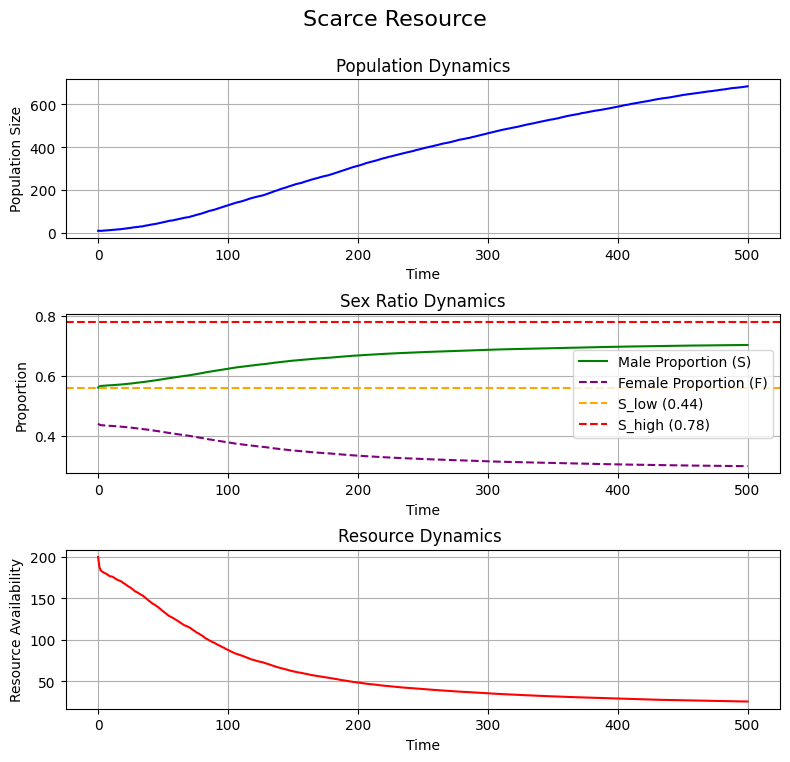

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
r = 0.1       # Growth rate
K0 = 1000     # Carrying capacity
S_low = 0.56  # Male proportion when resources are abundant
S_high = 0.78 # Male proportion when resources are scarce
beta = 1   # resource regeneration rate, high values(>1) will cause S to approach to S_low, vice versa
delta = 0.01 # resource depletion rate due to population
sigma = 0.01 # adjustment factor for resource dependency of sex ratio
R_max = 200   # Maximum resource availability

noise_intensity = 0.5  # Intensity of the stochastic noise


# Initial conditions
N0 = 10  # Initial population
R0 = R_max  # Abundant initial resources
S0 = S_low  # Initial male proportion, since resource is abundant, we start with S_low
X0 = [N0, R0, S0]

# Time span
tmax = 500
Nt = 500
t = np.linspace(0, tmax, Nt)

# Derivative function
def derivative(t, X, r, K0, beta, delta, R_max, S_low, S_high, sigma):
    N, R, S = X
    R = max(R, 0)  # Resources cannot be negative

    # dotN = r * (1 - S) * N * (1 - N / K0) * (R/R_max)  # Logistic growth with female contribution
    dotN = r * (1 - S) * N * (1 - N / K0) * (R/R_max) + noise_intensity * np.random.normal(0, 1)  # Logistic growth with female contribution and stochastic term
    dotR = beta * (R_max - R) - delta * N * R   # Resource dynamics
    dotS = (-(S_high - S_low) * sigma * np.exp(-sigma * R)) * dotR    # male ratio dynamics

    return [dotN, dotR, dotS]


t_span = [t[0], t[-1]]
sol = solve_ivp(
    derivative,
    t_span,
    X0,
    args=(r, K0, beta, delta, R_max, S_low, S_high, sigma),
    t_eval=t,
    method='RK45'
)

N = sol.y[0]
R = sol.y[1]
S = sol.y[2]

# Ensure non-negative values
N = np.maximum(N, 0)
R = np.maximum(R, 0)
S = np.clip(S, 0, 1)
F = 1 - S  # Female proportion is complementary to male proportion

# Plot results
plt.figure(figsize=(8, 10))
plt.suptitle("Scarce Resource", fontsize=16, y=0.95)

# Plot Population
plt.subplot(4, 1, 1)
plt.plot(t, N, label="Population (N)", color="blue")
plt.xlabel("Time")
plt.ylabel("Population Size")
plt.title("Population Dynamics")
plt.grid()

# Plot Male and Female Proportion
plt.subplot(4, 1, 2)
plt.plot(t, S, label="Male Proportion (S)", color="green")
plt.plot(t, F, label="Female Proportion (F)", color="purple", linestyle="--")
plt.axhline(S_low, color="orange", linestyle="--", label="S_low (0.44)")
plt.axhline(S_high, color="red", linestyle="--", label="S_high (0.78)")
plt.xlabel("Time")
plt.ylabel("Proportion")
plt.title("Sex Ratio Dynamics")
plt.legend()
plt.grid()

# Plot Resources
plt.subplot(4, 1, 3)
plt.plot(t, R, label="Resources (R)", color="red")
plt.xlabel("Time")
plt.ylabel("Resource Availability")
plt.title("Resource Dynamics ")
plt.grid()


plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


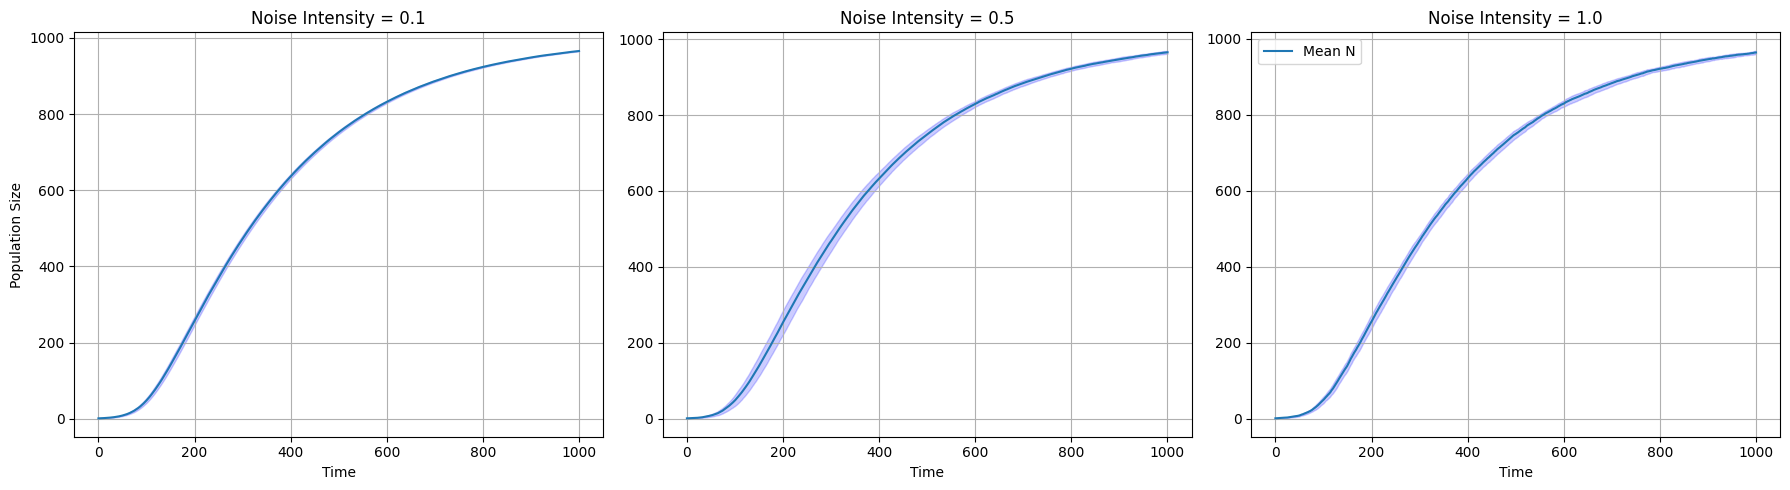

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
r = 0.1       # Growth rate
K0 = 1000     # Carrying capacity
S_low = 0.56  # Male proportion when resources are abundant
S_high = 0.78 # Male proportion when resources are scarce
beta = 1      # resource regeneration rate, high values(>1) will cause S to approach to S_low, vice versa
delta = 0.01  # resource depletion rate due to population
sigma = 0.01  # adjustment factor for resource dependency of sex ratio
R_max = 1   # Maximum resource availability
noise_intensities = [0.1, 0.5, 1.0]  # Increased noise intensities
num_simulations = 10  # Number of simulations for each noise intensity

# Initial conditions
N0 = 1  # Initial population
R0 = R_max  # Abundant initial resources
S0 = S_low  # Initial male proportion, since resource is abundant, we start with S_low
X0 = [N0, R0, S0]

# Time span
tmax = 1000  # Extended time span
Nt = 1000
t = np.linspace(0, tmax, Nt)

# Derivative function with stochastic term
def derivative(t, X, r, K0, beta, delta, R_max, S_low, S_high, sigma, noise_intensity):
    N, R, S = X
    R = max(R, 0)  # Resources cannot be negative

    dotN = r * (1 - S) * N * (1 - N / K0) * (R/R_max) + noise_intensity * np.random.normal(0, 1)  # Logistic growth with female contribution and stochastic term
    dotR = beta * (R_max - R) - delta * N * R   # Resource dynamics
    dotS = (-(S_high - S_low) * sigma * np.exp(-sigma * R)) * dotR    # male ratio dynamics

    return [dotN, dotR, dotS]

# Create subplots
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, noise_intensity in enumerate(noise_intensities):
    all_N = []
    for _ in range(num_simulations):
        t_span = [t[0], t[-1]]
        sol = solve_ivp(
            derivative,
            t_span,
            X0,
            args=(r, K0, beta, delta, R_max, S_low, S_high, sigma, noise_intensity),
            t_eval=t,
            method='RK45'
        )

        N = sol.y[0]
        all_N.append(N)

    all_N = np.array(all_N)
    mean_N = np.mean(all_N, axis=0)
    std_N = np.std(all_N, axis=0)

    # Plot Population
    ax[i].plot(t, mean_N, label=f'Mean N')
    ax[i].fill_between(t, mean_N - std_N, mean_N + std_N, color='b', alpha=0.2)
    ax[i].set_title(rf'Noise Intensity = {noise_intensity}')
    ax[i].set_xlabel('Time')
    if i == 0:
        ax[i].set_ylabel('Population Size')
    ax[i].grid()

plt.legend()
plt.tight_layout()
plt.show()


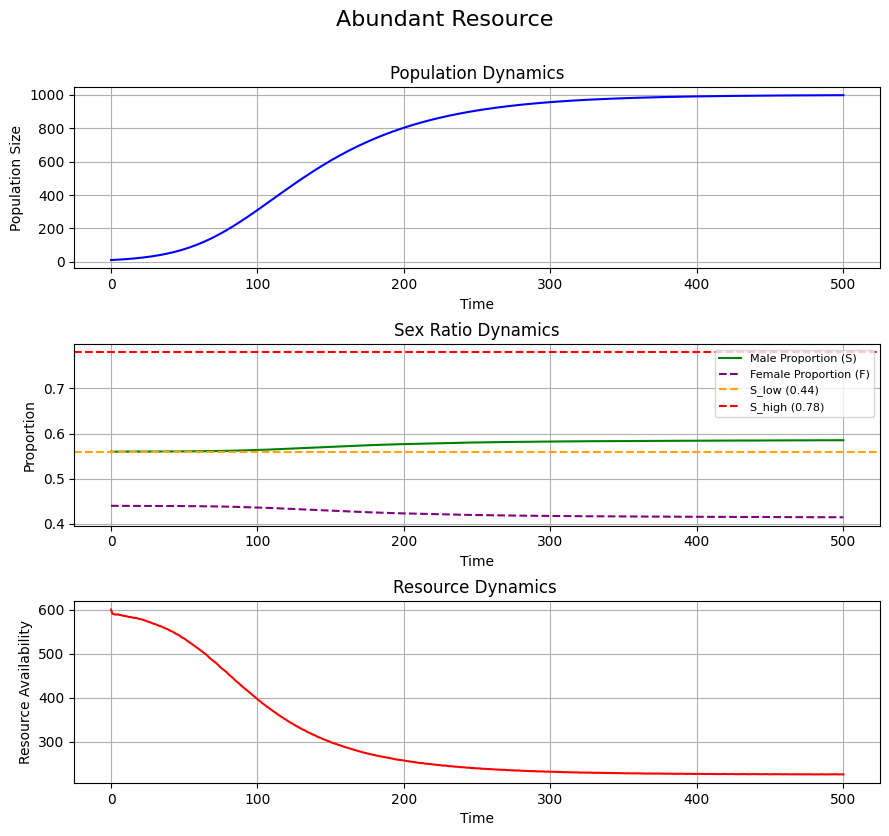

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
r = 0.1       # Growth rate
K0 = 1000     # Carrying capacity
S_low = 0.56  # Male proportion when resources are abundant
S_high = 0.78 # Male proportion when resources are scarce
beta = 3   # resource regeneration rate, high values(>1) will cause S to approach to S_low, vice versa
delta = 0.005 # resource depletion rate due to population
sigma = 0.01 # adjustment factor for resource dependency of sex ratio
R_max = 600   # Maximum resource availability

# Initial conditions
N0 = 10  # Initial population
R0 = R_max  # Abundant initial resources
S0 = S_low  # Initial male proportion, since resource is abundant, we start with S_low
X0 = [N0, R0, S0]

# Time span
tmax = 500
Nt = 500
t = np.linspace(0, tmax, Nt)

# Derivative function
def derivative(t, X, r, K0, beta, delta, R_max, S_low, S_high, sigma):
    N, R, S = X
    R = max(R, 0)  # Resources cannot be negative

    dotN = r * (1 - S) * N * (1 - N / K0) * (R/R_max)  # Logistic growth with female contribution
    dotR = beta * (R_max - R) - delta * N * R   # Resource dynamics
    dotS = (-(S_high - S_low) * sigma * np.exp(-sigma * R)) * dotR    # male ratio dynamics

    return [dotN, dotR, dotS]


t_span = [t[0], t[-1]]
sol = solve_ivp(
    derivative,
    t_span,
    X0,
    args=(r, K0, beta, delta, R_max, S_low, S_high, sigma),
    t_eval=t,
    method='RK45'
)

N = sol.y[0]
R = sol.y[1]
S = sol.y[2]

# Ensure non-negative values
N = np.maximum(N, 0)
R = np.maximum(R, 0)
S = np.clip(S, 0, 1)
F = 1 - S  # Female proportion is complementary to male proportion

# Plot results
plt.figure(figsize=(9, 11))
plt.suptitle("Abundant Resource", fontsize=16, y=0.95)

# Plot Population
plt.subplot(4, 1, 1)
plt.plot(t, N, label="Population (N)", color="blue")
plt.xlabel("Time")
plt.ylabel("Population Size")
plt.title("Population Dynamics")
plt.grid()

# Plot Male and Female Proportion
plt.subplot(4, 1, 2)
plt.plot(t, S, label="Male Proportion (S)", color="green")
plt.plot(t, F, label="Female Proportion (F)", color="purple", linestyle="--")
plt.axhline(S_low, color="orange", linestyle="--", label="S_low (0.44)")
plt.axhline(S_high, color="red", linestyle="--", label="S_high (0.78)")
plt.xlabel("Time")
plt.ylabel("Proportion")
plt.title("Sex Ratio Dynamics")
plt.legend(fontsize=8)
plt.grid()

# Plot Resources
plt.subplot(4, 1, 3)
plt.plot(t, R, label="Resources (R)", color="red")
plt.xlabel("Time")
plt.ylabel("Resource Availability")
plt.title("Resource Dynamics ")
plt.grid()


plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


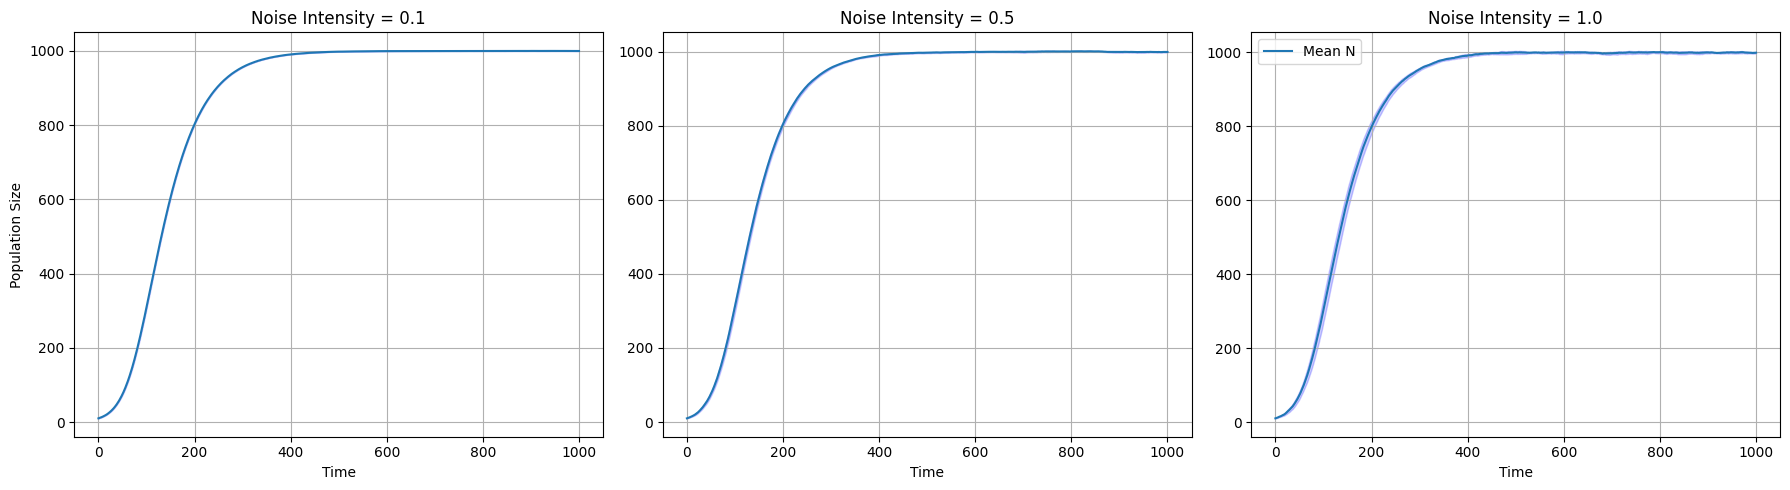

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
r = 0.1       # Growth rate
K0 = 1000     # Carrying capacity
S_low = 0.56  # Male proportion when resources are abundant
S_high = 0.78 # Male proportion when resources are scarce
beta = 3   # resource regeneration rate, high values(>1) will cause S to approach to S_low, vice versa
delta = 0.005 # resource depletion rate due to population
sigma = 0.01 # adjustment factor for resource dependency of sex ratio
R_max = 600   # Maximum resource availability

# Initial conditions
N0 = 10  # Initial population
R0 = R_max  # Abundant initial resources
S0 = S_low  # Initial male proportion, since resource is abundant, we start with S_low
X0 = [N0, R0, S0]

# Time span
tmax = 1000  # Extended time span
Nt = 1000
t = np.linspace(0, tmax, Nt)

# Derivative function with stochastic term
def derivative(t, X, r, K0, beta, delta, R_max, S_low, S_high, sigma, noise_intensity):
    N, R, S = X
    R = max(R, 0)  # Resources cannot be negative

    dotN = r * (1 - S) * N * (1 - N / K0) * (R/R_max) + noise_intensity * np.random.normal(0, 1)  # Logistic growth with female contribution and stochastic term
    dotR = beta * (R_max - R) - delta * N * R   # Resource dynamics
    dotS = (-(S_high - S_low) * sigma * np.exp(-sigma * R)) * dotR    # male ratio dynamics

    return [dotN, dotR, dotS]

# Create subplots
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, noise_intensity in enumerate(noise_intensities):
    all_N = []
    for _ in range(num_simulations):
        t_span = [t[0], t[-1]]
        sol = solve_ivp(
            derivative,
            t_span,
            X0,
            args=(r, K0, beta, delta, R_max, S_low, S_high, sigma, noise_intensity),
            t_eval=t,
            method='RK45'
        )

        N = sol.y[0]
        all_N.append(N)

    all_N = np.array(all_N)
    mean_N = np.mean(all_N, axis=0)
    std_N = np.std(all_N, axis=0)

    # Plot Population
    ax[i].plot(t, mean_N, label=f'Mean N')
    ax[i].fill_between(t, mean_N - std_N, mean_N + std_N, color='b', alpha=0.2)
    ax[i].set_title(rf'Noise Intensity = {noise_intensity}')
    ax[i].set_xlabel('Time')
    if i == 0:
        ax[i].set_ylabel('Population Size')
    ax[i].grid()

plt.legend()
plt.tight_layout()
plt.show()